# 01 — Data

Everything the project uses is built in this notebook; all later notebooks only *load* the files produced here.

| Source | Content | Raw file(s) |
|---|---|---|
| Yahoo Finance | Front-month **futures** ZC=F (corn), ZS=F (soybean), 2005–2026, cents/bushel | `data/raw/futures_*.csv` |
| Yahoo Finance | Commodity **ETFs** CORN, SOYB, WEAT (Teucrium) and COTN.L (WisdomTree cotton), 2011–2026 | `data/raw/etf_*.csv` |
| Open-Meteo archive | Daily weather for 12 growing locations, 15 crop-stress variables each | `data/raw/weather_*.csv` |

**Futures vs ETFs.** Yahoo's continuous futures series always shows the nearest contract, so it jumps at every roll date; the jumps have nothing to do with the underlying price process. We noticed this after the first strategies (notebook 02) were built on futures, and from then on used ETFs, which roll internally. The futures series is kept because it has the longest history (2005 onwards) — its results should be read with this caveat.

**Weather.** 30-day backward-looking aggregates are formed per variable (sums for precipitation / evapotranspiration, minima for soil moisture, maxima for wind, means otherwise) and forward-filled onto trading days, so each trading day only sees past weather.

Outputs:
* `data/processed/futures_corn_soybean.csv` — corn and soybean futures closes (notebook 02)
* `data/processed/full_dataset.csv` — ETF closes + 180 rolling weather features (notebooks 03–06)

In [1]:
import sys
sys.path.insert(0, '..')

import matplotlib.pyplot as plt
import pandas as pd

from src.data import (ETF_TICKERS, FUTURES_TICKERS, LOCATIONS, fetch_yahoo, fetch_weather,
                      build_full_dataset, build_futures_dataset, load_etf_prices,
                      save_figure)

# The raw files are committed in data/raw/. Set to True to re-download
# everything (needs internet; results will then differ slightly).
DOWNLOAD = False

## 1. Download (optional)

In [2]:
if DOWNLOAD:
    for name, ticker in FUTURES_TICKERS.items():
        fetch_yahoo(ticker, name, prefix='futures', start='2005-01-01')
    for name, ticker in ETF_TICKERS.items():
        fetch_yahoo(ticker, name, prefix='etf')
    for region in LOCATIONS:
        fetch_weather(region, start_date='2005-01-01')

pd.DataFrame([(region, loc, lat, lon) for region, locs in LOCATIONS.items()
              for loc, (lat, lon) in locs.items()],
             columns=['region', 'location', 'lat', 'lon']).set_index(['region', 'location'])

lat    lon
region location                     
us     central_iowa      42.0  -93.5
       central_illinois  40.1  -89.4
       central_indiana   40.0  -86.2
brazil mato_grosso      -12.6  -55.5
       parana           -24.0  -51.5
       rio_grande_sul   -29.5  -53.0
wheat  kansas            38.5  -98.0
       oklahoma          35.5  -97.5
       north_dakota      47.0 -100.0
cotton korla             41.8   86.1
       rajkot            22.3   70.8
       nagpur            21.1   79.1

## 2. Build the processed datasets

In [3]:
futures = build_futures_dataset()
full = build_full_dataset()

futures_corn_soybean.csv: 5303 trading days (2005-01-03 to 2026-02-02)


full_dataset.csv: 3754 trading days (2011-09-19 to 2026-04-24), 4 price + 180 weather columns


## 3. Overview

Corn and soybean move together (they compete for the same acreage and are both driven by feed demand and US weather), which motivates trading their spread. Note the level of the ETFs: they lose value over time through the roll yield of the underlying futures, one more reason to trade spreads rather than outright positions.

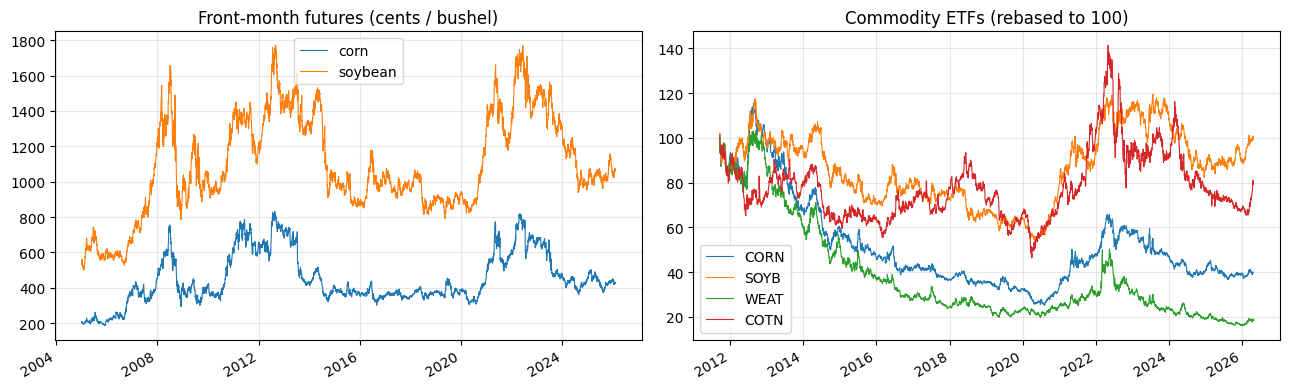

In [4]:
etf = load_etf_prices()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
futures.plot(ax=axes[0], lw=0.8)
axes[0].set_title('Front-month futures (cents / bushel)')
(100 * etf / etf.iloc[0]).plot(ax=axes[1], lw=0.8)
axes[1].set_title('Commodity ETFs (rebased to 100)')
for ax in axes:
    ax.set_xlabel('')
    ax.grid(alpha=0.3)
plt.tight_layout()
save_figure(fig, 'prices')
plt.show()

In [5]:
summary = pd.DataFrame({
    'first date': [futures.index[0].date(), etf.index[0].date()],
    'last date':  [futures.index[-1].date(), etf.index[-1].date()],
    'trading days': [len(futures), len(etf)],
    'assets': [', '.join(futures.columns), ', '.join(etf.columns)],
}, index=['futures (notebook 02)', 'ETFs (notebooks 03-06)'])
summary

,first date,last date,trading days,assets
futures (notebook 02),2005-01-03,2026-02-02,5303,"corn, soybean"
ETFs (notebooks 03-06),2011-09-19,2026-04-23,3604,"CORN, SOYB, WEAT, COTN"
